### 데이터 다운로드 및 mlflow logging 준비

In [4]:
import os
import boto3
import pandas as pd

# S3에서 데이터 다운로드
s3_bucket = "smwu-cv-team-4"
s3_prefix = "yolo_data"
local_data_path = "../yolo_data"

os.makedirs(local_data_path, exist_ok=True)
s3 = boto3.client('s3')

# 데이터 다운로드 함수
def download_s3_folder(bucket_name, s3_folder, local_dir):
    paginator = s3.get_paginator('list_objects_v2')
    for page in paginator.paginate(Bucket=bucket_name, Prefix=s3_folder):
        if "Contents" in page:
            for obj in page["Contents"]:
                s3_file_path = obj["Key"]
                local_file_path = os.path.join(local_dir, os.path.relpath(s3_file_path, s3_folder))
                os.makedirs(os.path.dirname(local_file_path), exist_ok=True)
                s3.download_file(bucket_name, s3_file_path, local_file_path)

download_s3_folder(s3_bucket, s3_prefix, local_data_path)


In [8]:
import mlflow

tracking_url = "http://54.81.40.145:5000/"

# MLflow Tracking URI 설정
mlflow.set_tracking_uri(tracking_url)


### EfficientNet Run

In [20]:
# epoch 10

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
import os
import mlflow
import mlflow.pytorch

# 데이터 경로
image_dir = "./data_yolo"

# 이미지 변환
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # 1채널 이미지를 3채널로 변환
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 3채널 평균과 표준편차
])

# 데이터셋 로드
train_data = datasets.ImageFolder(os.path.join(image_dir, 'train/images'), transform=transform)
val_data = datasets.ImageFolder(os.path.join(image_dir, 'val/images'), transform=transform)

# DataLoader 정의
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

# EfficientNet 모델 불러오기
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(pretrained=True)
num_features = model.classifier[1].in_features  # 마지막 레이어 입력 피처 수
model.classifier[1] = nn.Linear(num_features, 2)  # 이진 분류 출력 레이어로 수정
model = model.to(device)

# 손실 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 및 검증 함수
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy

# MLflow 실험 설정
mlflow.set_experiment("binaryClass_hyunji")

# 학습 루프
num_epochs = 10
best_val_accuracy = 0.0

with mlflow.start_run():  # 실험 시작
    # 모델 파라미터 기록
    mlflow.log_param("model", "EfficientNet-B0")
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("batch_size", 16)
    
    for epoch in range(num_epochs):
        # 훈련 및 검증
        train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = validate(model, val_loader, criterion, device)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

        # MLflow 기록
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_accuracy", train_accuracy, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("val_accuracy", val_accuracy, step=epoch)

        # 모델 저장
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            # MLflow에 모델 저장
            mlflow.pytorch.log_model(model, "model")
            print("Saved best model!")

    print("Training complete!")


Epoch 1/10
Train Loss: 0.0923, Train Accuracy: 0.9730
Val Loss: 0.1030, Val Accuracy: 0.9780


2024/11/22 12:25:37 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpel97bxw2/model/data, flavor: pytorch). Fall back to return ['torch==2.2.2', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2024/11/22 12:25:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Saved best model!
Epoch 2/10
Train Loss: 0.0588, Train Accuracy: 0.9813
Val Loss: 0.0575, Val Accuracy: 0.9742
Epoch 3/10
Train Loss: 0.0403, Train Accuracy: 0.9857
Val Loss: 0.0538, Val Accuracy: 0.9847


2024/11/22 12:27:14 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpn11h9eky/model/data, flavor: pytorch). Fall back to return ['torch==2.2.2', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2024/11/22 12:27:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Saved best model!
Epoch 4/10
Train Loss: 0.0267, Train Accuracy: 0.9921
Val Loss: 0.0500, Val Accuracy: 0.9866


...

Saved best model!
Epoch 5/10
Train Loss: 0.0202, Train Accuracy: 0.9936
Val Loss: 0.0332, Val Accuracy: 0.9904


2024/11/22 12:28:57 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpwud30dok/model/data, flavor: pytorch). Fall back to return ['torch==2.2.2', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2024/11/22 12:28:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Saved best model!
Epoch 6/10
Train Loss: 0.0246, Train Accuracy: 0.9917
Val Loss: 0.0934, Val Accuracy: 0.9618
Epoch 7/10
Train Loss: 0.0136, Train Accuracy: 0.9962
Val Loss: 0.0415, Val Accuracy: 0.9818
Epoch 8/10
Train Loss: 0.0099, Train Accuracy: 0.9971
Val Loss: 0.0494, Val Accuracy: 0.9895
Epoch 9/10
Train Loss: 0.0226, Train Accuracy: 0.9917
Val Loss: 0.0498, Val Accuracy: 0.9751


2024/11/22 12:32:49 INFO mlflow.tracking._tracking_service.client: 🏃 View run orderly-seal-49 at: http://54.81.40.145:5000/#/experiments/2/runs/a3baf50785de46b589c444136f5c4e2b.
2024/11/22 12:32:49 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://54.81.40.145:5000/#/experiments/2.


Epoch 10/10
Train Loss: 0.0220, Train Accuracy: 0.9936
Val Loss: 0.0579, Val Accuracy: 0.9837
Training complete!


In [21]:
# early stopping 도입

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
import os
import mlflow
import mlflow.pytorch
import numpy as np

# 데이터 경로
image_dir = "./data_yolo"

# 데이터셋 로드
train_data = datasets.ImageFolder(os.path.join(image_dir, 'train/images'), transform=transform)
val_data = datasets.ImageFolder(os.path.join(image_dir, 'val/images'), transform=transform)

# DataLoader 정의
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

# EfficientNet 모델 불러오기
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(pretrained=True)
num_features = model.classifier[1].in_features  # 마지막 레이어 입력 피처 수
model.classifier[1] = nn.Linear(num_features, 2)  # 이진 분류 출력 레이어로 수정
model = model.to(device)

# 손실 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 및 검증 함수
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy

# MLflow 실험 설정
mlflow.set_experiment("binaryClass_hyunji")

# Early Stopping 파라미터 설정
patience = 3  # 성능 개선이 없을 때 중단할 에포크 수
best_val_accuracy = 0.0
epochs_without_improvement = 0  # 성능 개선이 없었던 에포크 수

# 학습 루프
num_epochs = 50  # 충분히 많은 에포크 수 설정
with mlflow.start_run():  # 실험 시작
    # 모델 파라미터 기록
    mlflow.log_param("model", "EfficientNet-B0")
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("batch_size", 16)

    for epoch in range(num_epochs):
        # 훈련 및 검증
        train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = validate(model, val_loader, criterion, device)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

        # MLflow 기록
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_accuracy", train_accuracy, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("val_accuracy", val_accuracy, step=epoch)

        # 모델 저장
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), "best_model.pth")
            mlflow.pytorch.log_model(model, "model")  # 모델을 MLflow에 기록
            print("Saved best model!")
            epochs_without_improvement = 0  # 성능 향상된 경우 카운트를 리셋
        else:
            epochs_without_improvement += 1

        # Early Stopping 적용
        if epochs_without_improvement >= patience:
            print("Early stopping triggered. No improvement in validation accuracy.")
            break

    print("Training complete!")


Epoch 1/50
Train Loss: 0.0935, Train Accuracy: 0.9682
Val Loss: 0.0558, Val Accuracy: 0.9828


2024/11/22 12:34:57 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp9jp5pyp9/model/data, flavor: pytorch). Fall back to return ['torch==2.2.2', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2024/11/22 12:34:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Saved best model!
Epoch 2/50
Train Loss: 0.0474, Train Accuracy: 0.9835
Val Loss: 0.0421, Val Accuracy: 0.9799
Epoch 3/50
Train Loss: 0.0406, Train Accuracy: 0.9886
Val Loss: 0.0876, Val Accuracy: 0.9847


2024/11/22 12:36:36 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpghdv20w_/model/data, flavor: pytorch). Fall back to return ['torch==2.2.2', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2024/11/22 12:36:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Saved best model!
Epoch 4/50
Train Loss: 0.0193, Train Accuracy: 0.9943
Val Loss: 0.0402, Val Accuracy: 0.9885


...

Saved best model!
Epoch 5/50
Train Loss: 0.0315, Train Accuracy: 0.9870
Val Loss: 0.0291, Val Accuracy: 0.9914


2024/11/22 12:38:19 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp4c_gjez0/model/data, flavor: pytorch). Fall back to return ['torch==2.2.2', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2024/11/22 12:38:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Saved best model!
Epoch 6/50
Train Loss: 0.0181, Train Accuracy: 0.9930
Val Loss: 0.0419, Val Accuracy: 0.9895
Epoch 7/50
Train Loss: 0.0220, Train Accuracy: 0.9911
Val Loss: 0.0919, Val Accuracy: 0.9675


2024/11/22 12:40:38 INFO mlflow.tracking._tracking_service.client: 🏃 View run invincible-whale-223 at: http://54.81.40.145:5000/#/experiments/2/runs/1ac9f0cd76ef4b27ab70e4196bee456f.
2024/11/22 12:40:38 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://54.81.40.145:5000/#/experiments/2.


Epoch 8/50
Train Loss: 0.0244, Train Accuracy: 0.9921
Val Loss: 0.0296, Val Accuracy: 0.9904
Early stopping triggered. No improvement in validation accuracy.
Training complete!


## EfficientNet + NG augmentation(flip only) + CNN feature extraction + Weighted Focal Loss

In [36]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import mlflow
import mlflow.pytorch
from PIL import Image
import random
from sklearn.metrics import precision_score, recall_score, f1_score

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --------------------------
# 데이터셋 클래스 정의
# --------------------------
# Dataset class definition
class CustomDataset(Dataset):
    def __init__(self, image_dir, label_dir, ng_transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.ng_transform = ng_transform
        self.image_paths = []
        self.labels = []

        # 이미지 경로와 라벨 읽기
        for image_name in os.listdir(image_dir):
            if image_name.endswith(('.jpg', '.png', '.jpeg')):  # 확장자 확인
                image_path = os.path.join(image_dir, image_name)
                label_path = os.path.join(label_dir, image_name.replace('.jpg', '.txt')
                                                     .replace('.png', '.txt')
                                                     .replace('.jpeg', '.txt'))

                # 이미지 경로 추가
                self.image_paths.append(image_path)

                # 라벨 결정: .txt 파일이 비어있으면 OK (1), 내용이 있으면 NG (0)
                if os.path.exists(label_path):
                    with open(label_path, 'r') as f:
                        content = f.read().strip()
                        self.labels.append(0 if content else 1)  # NG: 0, OK: 1
                else:
                    self.labels.append(1)  # 라벨 파일이 없으면 기본적으로 OK로 설정

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx])
        label = self.labels[idx]

        # Apply transformations
        if label == 0 and self.ng_transform:  # Apply NG transformation
            image = self.ng_transform(image)
        # Always convert the image to a tensor
        image = transforms.ToTensor()(image)

        return image, label



# --------------------------
# 데이터 준비 및 Augmentation
# --------------------------
# 데이터 경로 설정
data_dir = "/home/ec2-user/SageMaker/yolo_data"
train_images_dir = os.path.join(data_dir, "train/images")
val_images_dir = os.path.join(data_dir, "valid/images")
train_label_dir = os.path.join(data_dir, "train/labels")
val_label_dir = os.path.join(data_dir, "valid/labels")

ng_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
])

# 데이터셋 로드
train_dataset = CustomDataset(train_images_dir, train_label_dir, ng_transform=ng_transform)
val_dataset = CustomDataset(val_images_dir, val_label_dir, ng_transform=None)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, pin_memory=True)

# ------------------------
# 모델 정의: EfficientNet
# ------------------------
# Pretrained EfficientNet 불러오기
model = models.efficientnet_b0(pretrained=True)

# Feature Extraction
for param in model.features.parameters():
    param.requires_grad = False  # Feature extraction을 위한 freezing

# Output layer 수정
model.classifier[1] = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2),  # OK/NG 이진 분류
)

model = model.to(device)


# 클래스별 데이터 수
num_ok = sum(label == 1 for label in train_dataset.labels)  # OK: 1
num_ng = sum(label == 0 for label in train_dataset.labels)  # NG: 0

# 클래스 가중치 계산
class_weights = torch.tensor([1.0 / num_ng, 1.0 / num_ok], device=device)

# Focal Loss에서 가중치 추가
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=self.alpha)

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return (1 - pt) ** self.gamma * ce_loss

criterion = FocalLoss(alpha=class_weights, gamma=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ----------------------
# 모델 학습 및 Early Stopping 루프
# ----------------------
def train(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=5, run_name=None):
    mlflow.set_experiment("binaryClass_hyunji")  # Experiment 설정
    best_val_loss = float("inf")
    patience_counter = 0  # Early Stopping을 위한 카운터

    with mlflow.start_run(run_name=run_name):  # Run 시작
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("learning_rate", optimizer.param_groups[0]['lr'])
        mlflow.log_param("batch_size", train_loader.batch_size)

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
            
            train_loss = running_loss / len(train_loader)

            # Validation 루프
            model.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            all_preds = []
            all_labels = []

            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

                    # 예측 결과 저장
                    _, predicted = torch.max(outputs, 1)
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

                    # Accuracy 계산
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 평균 Loss 및 Accuracy 계산
            validation_loss = val_loss / len(val_loader)
            accuracy = correct / total

            # Precision, Recall, F1 Score 계산
            from sklearn.metrics import precision_score, recall_score, f1_score

            precision = precision_score(all_labels, all_preds)
            recall = recall_score(all_labels, all_preds, average="weighted")
            f1 = f1_score(all_labels, all_preds, average="weighted")

            # MLflow에 Metric 기록
            mlflow.log_metric("val_loss", validation_loss, step=epoch)
            mlflow.log_metric("train_loss",train_loss,step=epoch)
            mlflow.log_metric("accuracy", accuracy, step=epoch)

            # Validation 결과 출력
            print(f"Epoch {epoch+1}/{epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {validation_loss:.4f}, "
                  f"Accuracy: {accuracy:.4f}, "
                  f"Precision: {precision:.4f}, "
                  f"Recall: {recall:.4f}, "
                  f"F1 Score: {f1:.4f}")

            # Early Stopping 체크
            if validation_loss < best_val_loss:
                best_val_loss = validation_loss
                patience_counter = 0  # 개선된 경우 카운터 초기화
                # 모델 저장
                model_save_path = f"best_model_binary_epoch_{epoch+1}.pth"
                torch.save(model.state_dict(), model_save_path)
                mlflow.log_artifact(model_save_path)
                print(f"Best model saved to {model_save_path}")
            else:
                patience_counter += 1
                print(f"No improvement for {patience_counter} epochs")

            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

# 모델 학습
train(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=3, run_name="EfficientNet_Run_4")


Using device: cuda


/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/50, Train Loss: 0.0310, Val Loss: 0.0042, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
Best model saved to best_model_binary_epoch_1.pth
Epoch 2/50, Train Loss: 0.0028, Val Loss: 0.0018, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
Best model saved to best_model_binary_epoch_2.pth
Epoch 3/50, Train Loss: 0.0008, Val Loss: 0.0007, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
Best model saved to best_model_binary_epoch_3.pth
Epoch 4/50, Train Loss: 0.0004, Val Loss: 0.0004, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
Best model saved to best_model_binary_epoch_4.pth
Epoch 5/50, Train Loss: 0.0005, Val Loss: 0.0002, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
Best model saved to best_model_binary_epoch_5.pth
Epoch 6/50, Train Loss: 0.0006, Val Loss: 0.0003, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
No improvement for 1 epochs
Ep

2024/11/26 08:21:27 INFO mlflow.tracking._tracking_service.client: 🏃 View run EfficientNet_Run_4 at: http://54.81.40.145:5000/#/experiments/2/runs/6710064d110e40f0ad2bf4aab31bc61b.
2024/11/26 08:21:27 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://54.81.40.145:5000/#/experiments/2.


Epoch 32/50, Train Loss: 0.0000, Val Loss: 0.0000, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
No improvement for 3 epochs
Early stopping triggered after 32 epochs.


### Test Function

In [ ]:
!pip install scikit-image

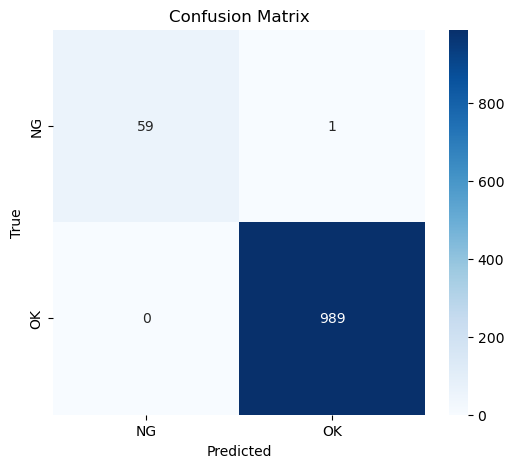

Test Loss: 0.0416
Precision: 0.9990
Recall: 0.9990
F1 Score: 0.9990
Confusion Matrix:
[[ 59   1]
 [  0 989]]


In [22]:
import torch
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import os
import boto3

# --------------------------
# 데이터 경로 설정
# --------------------------
data_dir = "/home/ec2-user/SageMaker/yolo_data/"
test_images_dir = os.path.join(data_dir, "test/images")
test_label_dir = os.path.join(data_dir, "test/labels")

# CustomDataset 및 DataLoader 정의
test_dataset = CustomDataset(test_images_dir, test_label_dir, ng_transform=None)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, pin_memory=True)

# S3에서 파일 다운로드
s3_bucket = 'smwu-cv-team-4'
s3_key = '2/6710064d110e40f0ad2bf4aab31bc61b/artifacts/best_model_binary_epoch_29.pth'
local_path = '/tmp/best_model_binary_epoch_29.pth'

# Boto3 S3 클라이언트 설정
s3 = boto3.client('s3')

# S3에서 로컬로 파일 다운로드
s3.download_file(s3_bucket, s3_key, local_path)

# EfficientNetB0 모델을 다시 정의한 후
model = models.efficientnet_b0(pretrained=False)  # pretrained=False로 모델 구조만 정의
model.classifier[1] = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2),  # OK/NG 이진 분류
)

# 모델에 가중치 로드
model.load_state_dict(torch.load(local_path))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 모델을 적절한 device로 이동
model = model.to(device)



# --------------------------
# MLflow 모델 로드
# --------------------------

# 모델 경로 (MLflow에서 모델이 저장된 경로)
# model_uri = "s3://smwu-cv-team-4/2/6710064d110e40f0ad2bf4aab31bc61b/artifacts/best_model_binary_epoch_29.pth"

# MLflow에서 모델 로드
# model = torch.load(model_uri)

# criterion = nn.CrossEntropyLoss()

# Focal Loss 가중치 계산
num_ng = 157  # NG 클래스의 샘플 수
num_ok = 4944  # OK 클래스의 샘플 수
class_weights = torch.tensor([1.0 / num_ng, 1.0 / num_ok], device=device)

# Focal Loss 정의
criterion = FocalLoss(alpha=class_weights, gamma=2)

# 모델 평가 함수
def evaluate_model_on_test_set(model, test_loader, criterion):
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # 예측 결과 저장
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 평균 Loss 계산
    avg_test_loss = test_loss / len(test_loader)

    # Precision, Recall, F1 Score 계산
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")

    # Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_preds)

    # Confusion Matrix 시각화
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NG', 'OK'], yticklabels=['NG', 'OK'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # 결과 출력
    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

# 모델 평가
evaluate_model_on_test_set(model, test_loader, criterion)



IndexError: list index out of range

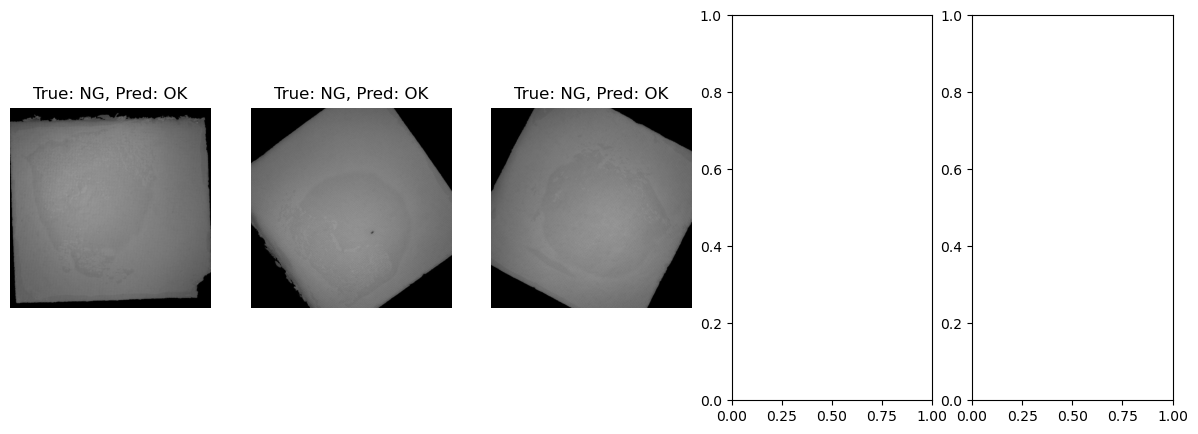

In [61]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# ------------------------
# 잘못 분류된 이미지 추출 및 시각화
# ------------------------

def get_misclassified_images(model, dataloader, device):
    model.eval()
    misclassified_images = []
    misclassified_labels = []
    misclassified_predictions = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            # NG인데 OK로 예측된 이미지만 필터링
            for i in range(len(labels)):
                if labels[i].item() == 0 and predicted[i].item() == 1:  # NG(0)인데 OK(1)로 분류된 경우
                    misclassified_images.append(inputs[i].cpu())
                    misclassified_labels.append(labels[i].cpu())
                    misclassified_predictions.append(predicted[i].cpu())

    return misclassified_images, misclassified_labels, misclassified_predictions

# ------------------------
# 잘못 분류된 이미지 출력
# ------------------------

def plot_misclassified_images(images, labels, predictions, classes=["NG", "OK"], num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    
    for i in range(num_images):
        axes[i].imshow(images[i].permute(1, 2, 0))  # 채널 차원을 맨 뒤로
        axes[i].set_title(f"True: {classes[labels[i]]}, Pred: {classes[predictions[i]]}")
        axes[i].axis("off")
    
    plt.show()

# ------------------------
# 모델과 데이터 로딩
# ------------------------

# 테스트 데이터셋 로드
data_dir = "./data_yolo"
test_images_dir = os.path.join(data_dir, "test/images")
test_dataset = CustomDataset(test_images_dir, transform=common_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 잘못 분류된 이미지 추출
misclassified_images, misclassified_labels, misclassified_predictions = get_misclassified_images(model, test_loader, device)

# 잘못 분류된 이미지 시각화 (최대 5개)
plot_misclassified_images(misclassified_images, misclassified_labels, misclassified_predictions, num_images=5)
